# Analýza návratnosti zákazníků podle prvního nákupu v kampani
Cílem je porovnat, jaká je návratnost zákazníků, jejichž první objednávka proběhla v kampani (`kampan_flag = 1`) versus bez kampaně (`kampan_flag = 0`).

Tato analýza je založená na pozorovacích datech, nikoli na experimentu, a ukazuje asociace, ne příčinné vazby.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
np.random.seed(42)

## 1) Načtení dat
Načteme data z CSV souboru a ověříme, že se načetla očekávaná struktura.

In [2]:
file_path = 'denormalizovany_dataset.csv'
df = pd.read_csv(file_path, parse_dates=['datum'])

print('Počet řádků:', len(df))
print('Sloupce:', df.columns.tolist())
print('\nDatové typy:')
print(df.dtypes)

df.head()

Počet řádků: 19500
Sloupce: ['id_objednavky', 'datum', 'zpusob_platby', 'id_pobocky', 'typ_nakupu', 'id_kampane', 'typ_zakaznik', 'id_zakaznik', 'poradi_objednavky', 'pohlavi', 'id_polozky', 'cena_polozka', 'mnozstvi', 'id_varianty', 'velikost', 'naklad', 'id_produktu', 'nazev', 'technika', 'druh', 'kampan_flag', 'kampan_nazev', 'start_datum', 'konec_datum', 'rozpocet_kampan', 'kanal', 'vyse_slevy']

Datové typy:
id_objednavky                 int64
datum                datetime64[us]
zpusob_platby                   str
id_pobocky                    int64
typ_nakupu                      str
id_kampane                  float64
typ_zakaznik                    str
id_zakaznik                   int64
poradi_objednavky             int64
pohlavi                         str
id_polozky                    int64
cena_polozka                  int64
mnozstvi                      int64
id_varianty                   int64
velikost                        str
naklad                        int64
id_prod

,id_objednavky,datum,zpusob_platby,id_pobocky,typ_nakupu,id_kampane,typ_zakaznik,id_zakaznik,poradi_objednavky,pohlavi,...,nazev,technika,druh,kampan_flag,kampan_nazev,start_datum,konec_datum,rozpocet_kampan,kanal,vyse_slevy
0,17119,2023-08-15,prevod,0,online,NaN,verny,1472,2,f,...,svetr basic,pletený,oblečení,0,NaN,NaN,NaN,NaN,NaN,NaN
1,12950,2018-08-28,hotovost,6,pobocka,NaN,verny,1125,2,f,...,svetr basic,pletený,oblečení,0,NaN,NaN,NaN,NaN,NaN,NaN
2,4277,2020-05-02,karta,0,online,NaN,prilezitostny,4519,1,f,...,svetr basic,pletený,oblečení,0,NaN,NaN,NaN,NaN,NaN,NaN
3,7662,2025-04-28,karta,0,online,NaN,verny,11,10,F,...,svetr basic,pletený,oblečení,0,NaN,NaN,NaN,NaN,NaN,NaN
4,7613,2016-07-18,prevod,0,online,NaN,prilezitostny,3460,1,F,...,svetr basic,pletený,oblečení,0,NaN,NaN,NaN,NaN,NaN,NaN


## 2) Kontrola základní struktury datasetu
Podíváme se na chybějící hodnoty, počet unikátních zákazníků a počet unikátních objednávek.

In [3]:
print('Chybějící hodnoty podle sloupce:')
print(df.isna().sum())

print('\nPočet unikátních zákazníků:', df['id_zakaznik'].nunique())
print('Počet unikátních objednávek:', df['id_objednavky'].nunique())
print('Počet řádků / objednávek:', len(df), '/', df['id_objednavky'].nunique())

Chybějící hodnoty podle sloupce:
id_objednavky            0
datum                    0
zpusob_platby            0
id_pobocky               0
typ_nakupu               0
id_kampane           16209
typ_zakaznik             0
id_zakaznik              0
poradi_objednavky        0
pohlavi                  3
id_polozky               0
cena_polozka             0
mnozstvi                 0
id_varianty              0
velikost                 0
naklad                   0
id_produktu              0
nazev                    0
technika                 0
druh                     0
kampan_flag              0
kampan_nazev         16209
start_datum          16209
konec_datum          16209
rozpocet_kampan      16209
kanal                16209
vyse_slevy           16209
dtype: int64

Počet unikátních zákazníků: 4864
Počet unikátních objednávek: 14670
Počet řádků / objednávek: 19500 / 14670


## 3) Převod dat na úroveň objednávky
Dataset může obsahovat více řádků pro jednu objednávku (např. produktové řádky). Pro analýzu návratnosti chceme pracovat s jednou řádkou za objednávku.

In [4]:
order_columns = ['id_objednavky', 'id_zakaznik', 'datum', 'kampan_flag', 'id_kampane', 'kanal', 'vyse_slevy', 'typ_zakaznik']

# Převedeme do úrovně objednávky. Pokud je objednávka rozložená na více řádků, sloučíme ji na jednu řádku.
df_orders = (
    df[order_columns]
    .sort_values(['id_objednavky', 'datum'])
    .groupby('id_objednavky', as_index=False)
    .agg(
        id_zakaznik=('id_zakaznik', 'first'),
        datum=('datum', 'first'),
        kampan_flag=('kampan_flag', 'max'),
        id_kampane=('id_kampane', 'first'),
        kanal=('kanal', 'first'),
        vyse_slevy=('vyse_slevy', 'sum'),
        typ_zakaznik=('typ_zakaznik', 'first')
    )
)

print('Počet řádků v původním datasetu:', len(df))
print('Počet řádků na úrovni objednávky:', len(df_orders))
df_orders.head()

Počet řádků v původním datasetu: 19500
Počet řádků na úrovni objednávky: 14670


,id_objednavky,id_zakaznik,datum,kampan_flag,id_kampane,kanal,vyse_slevy,typ_zakaznik
0,1,332,2018-09-26,0,NaN,NaN,0.0,verny
1,2,2446,2019-07-15,1,1.0,Email,30.0,prilezitostny
2,4,1116,2021-02-20,1,1.0,Email,30.0,verny
3,5,43,2021-11-07,1,1.0,Email,30.0,verny
4,6,6481,2018-12-27,1,1.0,Email,30.0,jednorazovy


## 4) Určení první objednávky každého zákazníka
Najdeme první objednávku každého zákazníka podle data a `id_objednavky`.

In [5]:
df_orders = df_orders.sort_values(['id_zakaznik', 'datum', 'id_objednavky'])
first_orders = (
    df_orders
    .groupby('id_zakaznik', as_index=False)
    .first()
)

print('Počet zákazníků:', len(first_orders))
first_orders[['id_zakaznik', 'datum', 'kampan_flag', 'id_objednavky']].head()

Počet zákazníků: 4864


,id_zakaznik,datum,kampan_flag,id_objednavky
0,1,2015-01-25,1,18004
1,2,2015-10-14,0,16736
2,3,2015-10-27,0,15210
3,4,2015-06-08,1,17438
4,5,2017-07-19,1,557


## 5) Vytvoření proměnné `first_campaign_flag`
Tato proměnná ukáže, zda první objednávka zákazníka proběhla v kampani.

In [6]:
first_orders = first_orders.rename(columns={'kampan_flag': 'first_campaign_flag'})
first_orders['first_campaign_flag'] = first_orders['first_campaign_flag'].astype(int)

first_orders[['id_zakaznik', 'datum', 'first_campaign_flag']].head()

,id_zakaznik,datum,first_campaign_flag
0,1,2015-01-25,1
1,2,2015-10-14,0
2,3,2015-10-27,0
3,4,2015-06-08,1
4,5,2017-07-19,1


## 6) Vytvoření `return_flag`
Vytvoříme příznak, že zákazník má více než jednu objednávku. To je naše definice návratnosti zákazníka.

In [7]:
customer_order_counts = (
    df_orders
    .groupby('id_zakaznik')
    .size()
    .reset_index(name='order_count')
)

customer_order_counts['return_flag'] = (customer_order_counts['order_count'] > 1).astype(int)
customer_order_counts.head()

,id_zakaznik,order_count,return_flag
0,1,14,1
1,2,12,1
2,3,12,1
3,4,11,1
4,5,11,1


## 7) Vytvoření customer-level datasetu
Spojíme první objednávku zákazníka s příznakem návratu.

In [8]:
customer_df = (
    first_orders
    .merge(customer_order_counts, on='id_zakaznik', how='left')
)

customer_df[['id_zakaznik', 'datum', 'first_campaign_flag', 'order_count', 'return_flag']].head()

# Kontrolní výpisy počtu zákazníků v obou skupinách
counts = customer_df['first_campaign_flag'].value_counts().sort_index()
print('Počet zákazníků s první objednávkou mimo kampaň (0):', counts.get(0, 0))
print('Počet zákazníků s první objednávkou v kampani (1):', counts.get(1, 0))

Počet zákazníků s první objednávkou mimo kampaň (0): 4070
Počet zákazníků s první objednávkou v kampani (1): 794


## 8) Výpočet návratnosti podle skupiny
Spočítáme podíl zákazníků, kteří se vrátili, v obou skupinách.

In [9]:
summary = (
    customer_df
    .groupby('first_campaign_flag')
    .agg(
        customers=('id_zakaznik', 'count'),
        returns=('return_flag', 'sum')
    )
    .reset_index()
)
summary['return_rate'] = summary['returns'] / summary['customers']
summary['return_rate_pct'] = summary['return_rate'] * 100
summary

,first_campaign_flag,customers,returns,return_rate,return_rate_pct
0,0,4070,3221,0.79140,79.140049
1,1,794,560,0.70529,70.528967


## 9) Rozdíl návratnosti v procentních bodech
Porovnáme návratnost zákazníků, jejichž první objednávka byla v kampani, s těmi, kteří ji neměli.

In [10]:
return_rate_campaign = summary.loc[summary['first_campaign_flag'] == 1, 'return_rate'].iloc[0]
return_rate_non_campaign = summary.loc[summary['first_campaign_flag'] == 0, 'return_rate'].iloc[0]

difference_pct_points = (return_rate_campaign - return_rate_non_campaign) * 100
print(f'Průměrná návratnost, první objednávka v kampani: {return_rate_campaign:.3f} ({return_rate_campaign*100:.2f} % )')
print(f'Průměrná návratnost, první objednávka bez kampaně: {return_rate_non_campaign:.3f} ({return_rate_non_campaign*100:.2f} % )')
print(f'Rozdíl: {difference_pct_points:.2f} procentních bodů')

Průměrná návratnost, první objednávka v kampani: 0.705 (70.53 % )
Průměrná návratnost, první objednávka bez kampaně: 0.791 (79.14 % )
Rozdíl: -8.61 procentních bodů


## 10) Bootstrap analýza rozdílu návratnosti
Pro odhad nejistoty použijeme bootstrap. Vytvoříme opakované vzorky zákazníků s náhradou v každé skupině a spočítáme rozdíl návratnosti.

In [11]:
boot_iterations = 2000
boot_diffs = []

campaign_customers = customer_df[customer_df['first_campaign_flag'] == 1]['return_flag'].values
non_campaign_customers = customer_df[customer_df['first_campaign_flag'] == 0]['return_flag'].values

for _ in range(boot_iterations):
    sample_campaign = np.random.choice(campaign_customers, size=len(campaign_customers), replace=True)
    sample_non_campaign = np.random.choice(non_campaign_customers, size=len(non_campaign_customers), replace=True)

    rate_campaign = sample_campaign.mean()
    rate_non_campaign = sample_non_campaign.mean()
    boot_diffs.append((rate_campaign - rate_non_campaign) * 100)

boot_diffs = np.array(boot_diffs)
ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])

print(f'Bootstrap 95% CI rozdílu: {ci_lower:.2f} až {ci_upper:.2f} procentních bodů')
print(f'Střední hodnota bootstrap rozdílu: {boot_diffs.mean():.2f} procentních bodů')

Bootstrap 95% CI rozdílu: -12.07 až -5.07 procentních bodů
Střední hodnota bootstrap rozdílu: -8.56 procentních bodů


## 11) Graf rozdělení bootstrap rozdílů
Vizualizace ukáže, jak se rozdíl návratnosti mezi skupinami rozprostírá v bootstrap vzorcích.

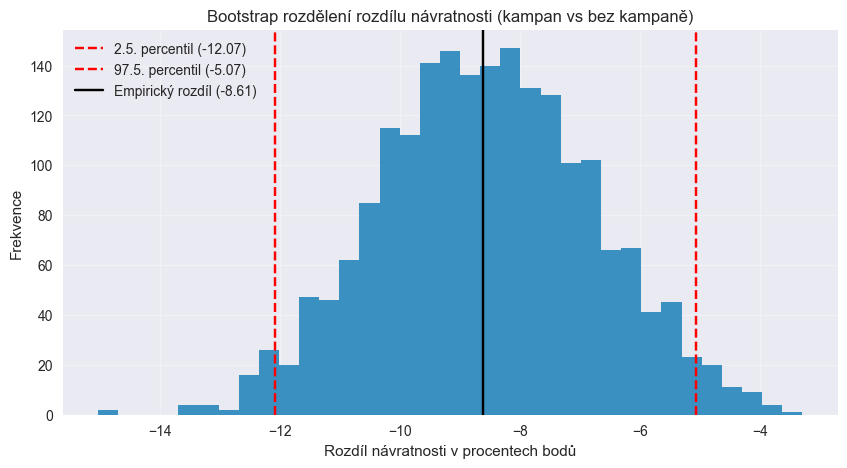

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(boot_diffs, bins=35, color='#0072B2', alpha=0.75)
plt.axvline(ci_lower, color='red', linestyle='--', label=f'2.5. percentil ({ci_lower:.2f})')
plt.axvline(ci_upper, color='red', linestyle='--', label=f'97.5. percentil ({ci_upper:.2f})')
plt.axvline(difference_pct_points, color='black', linestyle='-', label=f'Empirický rozdíl ({difference_pct_points:.2f})')
plt.title('Bootstrap rozdělení rozdílu návratnosti (kampan vs bez kampaně)')
plt.xlabel('Rozdíl návratnosti v procentech bodů')
plt.ylabel('Frekvence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12) Shrnutí a interpretace
- Vidíme, kolik zákazníků začíná první objednávkou v kampani versus bez kampaně.
- Poměr zákazníků, kteří mají více než jednu objednávku, se liší mezi oběma skupinami.
- Rozdíl v procentních bodech ukazuje asociaci mezi typem první objednávky a pravděpodobností dalšího nákupu.
- Protože se jedná o observační data, nelze z tohoto výsledku bezpečně usuzovat, že kampaň sama o sobě návratnost způsobila.
- Výsledek je užitečný pro další obchodní diskusi, ale je potřeba zohlednit možné skryté faktory a další analýzy.